# Experiment 1: Baseline CNN

In [17]:
import os
import tensorflow as tf

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

def normalise(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

def load_split(path, shuffle=False):
    # Load datasets as tf.data.Dataset from preprocessed image directories
    return tf.keras.utils.image_dataset_from_directory(
        path,
        class_names=CLASS_NAMES,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        color_mode="grayscale",
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

# Normalise pixel values and enable parallel prefetching. We'll shuffle the train set once more.
train_set = (load_split("processed_data/train", shuffle=True)
    .map(normalise, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE))

valid_set = (load_split("processed_data/val")
    .map(normalise, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE))

Found 4710 files belonging to 2 classes.
Found 524 files belonging to 2 classes.


In [19]:
for images, labels in train_set.take(1): # Quick inspection of a single batch
    print(f"Image batch shape: {images.shape}")  # 32 Samples, 244x244, 1 channel
    print(f"Label batch shape: {labels.shape}")  # 32 labels
    print(f"Pixel range: {images.numpy().min()} - {images.numpy().max()}")
    print(f"Batch labels: {labels.numpy()}")

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Pixel range: 0.0 - 1.0
Batch labels: [0 1 1 1 1 0 0 1 1 1 1 0 1 1 1 0 0 1 0 0 1 0 1 0 1 1 0 1 0 1 1 1]


## Model Construction and Training Loop

In [20]:
from pathlib import Path

# Create callbacks
CHECKPOINT_DIR = Path(".") / "checkpoints" / "BaselineCNN"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_DIR / "baselinecnn_epoch-{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_best_only=False, # Save weights for every epoch
    monitor="val_loss",
    mode="min",
    verbose=1
)
    
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

In [21]:
import glob
import numpy as np
from src.models import BaselineCNN

# Model initialisation and training parameters
baseline_cnn = BaselineCNN()
LEARNING_RATE = 1e-4
EPOCHS = 10

# Compile
baseline_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE # Fixed learning rate
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=["accuracy"]
)

# Load from checkpoints if exists
checkpoints = sorted(glob.glob(f"{CHECKPOINT_DIR}/*.weights.h5"))

if checkpoints:
    latest = checkpoints[-1]
    baseline_cnn(np.zeros((1, 224, 224, 1), dtype="float32")) # Force build of all sublayers
    baseline_cnn.load_weights(latest)
    print(model(np.zeros((1, 224, 224, 1), dtype="float32"), training=False))
    # Epoch number is contained within the filename
    initial_epoch = int(latest.split("epoch-")[1].split(".")[0])
    print(f"Loaded pretrained weights, resuming from {latest}. Retrain for history.")
else:
    initial_epoch = 0
    print("No checkpoints found, training from scratch.")

# Train
history = baseline_cnn.fit(
    train_set,
    validation_data=valid_set,
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    callbacks=[checkpoint_callback], # Feel free to experiment and add the early stopping callback too
    verbose=1
)

No checkpoints found, training from scratch.
Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.7291 - loss: 4.4774
Epoch 1: saving model to checkpoints/BaselineCNN/baselinecnn_epoch-01.weights.h5

Epoch 1: finished saving model to checkpoints/BaselineCNN/baselinecnn_epoch-01.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.8238 - loss: 1.5342 - val_accuracy: 0.9313 - val_loss: 0.1877
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9355 - loss: 0.1700
Epoch 2: saving model to checkpoints/BaselineCNN/baselinecnn_epoch-02.weights.h5

Epoch 2: finished saving model to checkpoints/BaselineCNN/baselinecnn_epoch-02.weights.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.9406 - loss: 0.1579 - val_accuracy: 0.9351 - val_loss: 0.1512
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7856 - loss: 4.1298
Epoch 3: saving model to checkpoints/BaselineCNN/baselinecnn_epoch-03.weights.h5

Epoch 3: finished saving 

## Training History

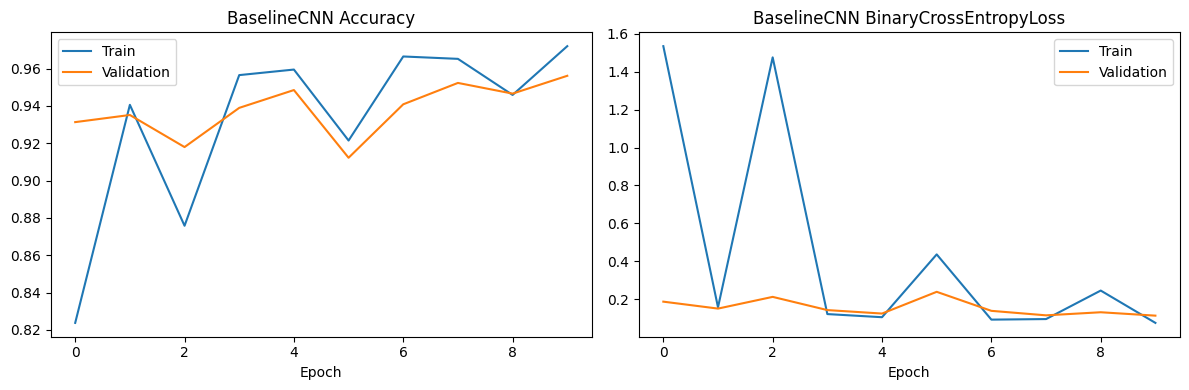

In [23]:
from src.plot import plot_history

FIG_DIR = Path(".") / "outputs" / "BaselineCNN"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "BaselineCNN"

plot_history(history, MODEL_NAME, FIG_DIR / "training_history.png")

## Evaluation

Run `Evaluation.ipynb`.